In [1]:
%cp -r ../resources .

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from Astrid.effective_area import (
    HESE_effective_areas, 
    bin_edges_to_centers, 
    bin_centers_to_edges,
    apply_energy_smearing
)
from scipy.interpolate import interp1d
from Astrid.data_processing import get_weights
from Astrid.config import MC_FILENAMES, PARAMS, PARAMETER_NAMES

import data_loader
import weighter
import binning
import gc

In [3]:
livetime = 227708167.68
energy_bins_original = np.logspace(2, 7, 5 * 20 + 1)  # Original energy bins
energy_bins = np.logspace(4, 7, 3 * 20 + 1)  # For initial effective area calculation, consistent with HESE original bins
energy_bins_plotting = np.logspace(4, 7, 28)      # For final plotting
energy_bins_high_resolution = np.logspace(4, 7, num=600+1)
gen2 = False


In [5]:
eff, eff_err = HESE_effective_areas(interaction_channels=True)

Final eff shape: (9, 100)


In [4]:
eff, eff_err = HESE_effective_areas(interaction_channels=False)

test
Final eff shape: (3, 100)


In [5]:
print(eff)

[array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.50233993e-04, 1.65503000e-03,
       5.21404898e-03, 2.20661413e-02, 4.31364661e-02, 9.36317161e-02,
       1.58180186e-01, 2.59069602e-01, 3.90220584e-01, 5.53704655e-01,
       7.74678143e-01, 1.09229589e+00, 1.61603315e+00, 2.11492616e+00,
     

Define effective area and Energy for the desired ranges using the same spacing as in HESE original effective areas

In [6]:
energy_bins_original_ = energy_bins_original[1:]
emin, emax = energy_bins[0], energy_bins[-1]
print(len(energy_bins_original_))
# Filter energy bins within the range of Edep
mask = (energy_bins_original_ > emin) & (energy_bins_original_ <= min(emax, 1e7))
#print('mask: ', mask)
print(len(mask))
energy_filtered = energy_bins_original_[mask]

# Extrapolate for Edep[-1] > 1e7
if emax > 1e7 + 10:
    delta_e = np.log10(emax) - np.log10(1e7)
    num_bins = int(delta_e) * 20  # Number of bins to extrapolate
    # Combine filtered and extrapolated energy bins
    energy_extrapolated = np.logspace(7, np.log10(emax), num=num_bins) 
    energy_combined = np.concatenate((energy_filtered, energy_extrapolated))

    # Combine the filtered area and projected area for each flavor
    #projected_eff = (2* 10 ** (0.29 * np.log10(energy_extrapolated) - 0.38))
    projected_eff = (10 ** (0.29 * np.log10(energy_extrapolated) - 0.38))
    eff_new = [
        np.concatenate((area[mask], projected_eff)) * (10 if gen2 else 1)
        for area in eff
    ]
else:
    print('No extrapolation needed')
    energy_extrapolated = []
    energy_combined = energy_filtered
    eff_new = [area[mask] * (10 if gen2 else 1) for area in eff]

print(len(eff_new[0]), len(energy_combined))
#print(eff_new)
#print(energy_combined)


100
100
No extrapolation needed
60 60


After the ranges of the effective area has been modified we put the first edge/element in energy_bins back, so that we can compute the right amount of bin centers in order to be consistent with the convention in the flux from nuSIprop

In [7]:
# Convert bin edges to centers
energy_edges_combined_ = np.concatenate(([energy_bins[0]], energy_combined))
energy_centers = bin_edges_to_centers(energy_edges_combined_)

eff_new = np.asarray(eff_new)

eff_df = pd.DataFrame(eff_new.T, index=energy_centers, columns=['nu_e', 'nu_mu', 'nu_tau'])
#eff_df = pd.DataFrame(eff_new.T, index=energy_centers, columns=['nu_e_CC', 'nu_e_NC', 'nu_e_GR', 'nu_mu_CC', 'nu_mu_NC', 'nu_mu_GR', 'nu_tau_CC', 'nu_tau_NC', 'nu_tau_GR'])
print(eff_df)
#eff_df.to_csv('effective_area_4_to_7_interaction_types.csv')



                    nu_e      nu_mu     nu_tau
1.059254e+04    0.000000   0.000000   0.000000
1.188502e+04    0.000000   0.000000   0.000000
1.333521e+04    0.000650   0.000000   0.000000
1.496236e+04    0.001655   0.000000   0.000164
1.678804e+04    0.005214   0.000231   0.000910
1.883649e+04    0.022066   0.001210   0.002558
2.113489e+04    0.043136   0.004113   0.009679
2.371374e+04    0.093632   0.006964   0.016494
2.660725e+04    0.158180   0.013907   0.046911
2.985383e+04    0.259070   0.030709   0.078405
3.349654e+04    0.390221   0.054082   0.131141
3.758374e+04    0.553705   0.082374   0.226340
4.216965e+04    0.774678   0.129672   0.341698
4.731513e+04    1.092296   0.216925   0.507006
5.308844e+04    1.616033   0.291094   0.687900
5.956621e+04    2.114926   0.452367   0.961127
6.683439e+04    2.826941   0.654275   1.425661
7.498942e+04    3.440951   0.891118   1.751250
8.413951e+04    4.221091   1.235720   2.431535
9.440609e+04    5.163777   1.650396   2.969325
1.059254e+05 

60


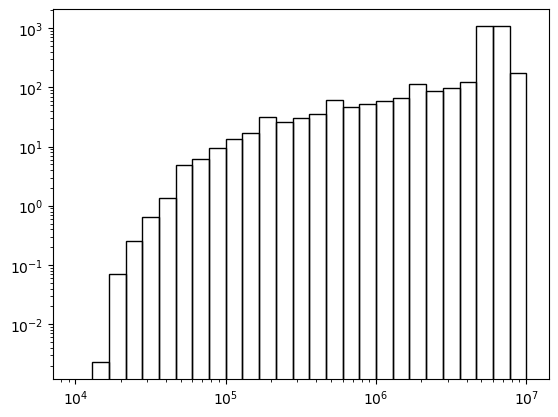

In [13]:
print(len(eff_df.index.values))
plt.hist(eff_df.index.values, bins=energy_bins_plotting, weights=eff_df['nu_e'].values, log=True, fill=False)
plt.xscale('log')
plt.show()

In [8]:
print(energy_edges_combined_)
assert energy_combined.all() == energy_bins.all()

[   10000.            11220.18454302    12589.25411794    14125.37544623
    15848.93192461    17782.79410039    19952.62314969    22387.21138568
    25118.8643151     28183.82931264    31622.77660168    35481.33892336
    39810.71705535    44668.3592151     50118.72336273    56234.13251903
    63095.73444802    70794.57843841    79432.82347243    89125.09381337
   100000.           112201.8454302    125892.54117942   141253.75446228
   158489.31924611   177827.94100389   199526.23149689   223872.11385683
   251188.64315096   281838.29312645   316227.76601684   354813.38923358
   398107.1705535    446683.59215096   501187.23362727   562341.32519035
   630957.34448019   707945.78438414   794328.23472428   891250.93813375
  1000000.          1122018.45430196  1258925.41179417  1412537.54462276
  1584893.19246111  1778279.41003892  1995262.31496888  2238721.13856834
  2511886.43150958  2818382.93126445  3162277.66016838  3548133.89233575
  3981071.70553498  4466835.92150963  5011872.33627

Read the pre generated flux from nuSIprop. Convert the indices to GeV to be consistent with HESE. Then compute delta_E (bin width) using the bin edges.

In [14]:
nuSIprop_df = pd.read_csv('../Astrid/flux/flux_Fig6_600bins.csv', index_col=0)
nuSIprop_df.index = nuSIprop_df.index / 1e9    # Convert to [GeV]
nuSIprop_bin_centers = nuSIprop_df.index.values
nuSIprop_bin_edges = bin_centers_to_edges(nuSIprop_bin_centers)
nuSIprop_delta_E = np.diff(nuSIprop_bin_edges)
print("Flux data bins:", len(nuSIprop_bin_centers))

Flux data bins: 600


Interpolating effective area as the flux from nuSIProp so that the bins go from 60 to 600, than computing the total events

In [15]:
norm = 0.8*1e-12

eff_interpolated = pd.DataFrame(
    {col: interp1d(
        eff_df.index, 
        eff_df[col], 
        bounds_error=False, 
        fill_value="extrapolate")(nuSIprop_df.index) 
        for col in eff_df.columns
    },
    index=nuSIprop_df.index
)



nuSIprop_events_df = eff_interpolated * nuSIprop_df * livetime * norm 
print(nuSIprop_events_df)
negative_mask = nuSIprop_events_df < 0
nuSIprop_events_df[negative_mask] = 0
    
#total_events_df = flx * eff_interpolated * livetime
nuSIprop_events_df['total_events'] = nuSIprop_delta_E * (nuSIprop_events_df['nu_e'] + nuSIprop_events_df['nu_mu'] + nuSIprop_events_df['nu_tau'])
#total_events_df.index = eff.index 
display(nuSIprop_events_df)

                      nu_e         nu_mu        nu_tau
1.005773e+04  0.000000e+00  0.000000e+00  0.000000e+00
1.017419e+04  0.000000e+00  0.000000e+00  0.000000e+00
1.029201e+04  0.000000e+00  0.000000e+00  0.000000e+00
1.041118e+04  0.000000e+00  0.000000e+00  0.000000e+00
1.053174e+04  0.000000e+00  0.000000e+00  0.000000e+00
...                    ...           ...           ...
9.495110e+06  1.194904e-07  7.679983e-08  9.867900e-08
9.605058e+06  1.159012e-07  7.536181e-08  9.644218e-08
9.716280e+06  1.125045e-07  7.402428e-08  9.434709e-08
9.828789e+06  1.093121e-07  7.280964e-08  9.241571e-08
9.942601e+06  1.063298e-07  7.172678e-08  9.065677e-08

[600 rows x 3 columns]


,nu_e,nu_mu,nu_tau,total_events
1.005773e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1.017419e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1.029201e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1.041118e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1.053174e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
...,...,...,...,...
9.495110e+06,1.194904e-07,7.679983e-08,9.867900e-08,0.032245
9.605058e+06,1.159012e-07,7.536181e-08,9.644218e-08,0.031815
9.716280e+06,1.125045e-07,7.402428e-08,9.434709e-08,0.031420
9.828789e+06,1.093121e-07,7.280964e-08,9.241571e-08,0.031066


Getting the MC events and weights that correspond to the astrophysical flux. As they are numerous (on the order of 1e5-1e6), it is better to scale them down to 600 (same as the nuSIprop flux) before smearing.

Shadowed code is the old version that might contain the background events. 

In [25]:
# Get MC weights.
mc_test, mc_weights_test = get_weights(energy_bins_high_resolution, livetime=livetime, gen2=gen2, background=False)

In [16]:
mc = data_loader.load_mc(MC_FILENAMES, emin=energy_bins[0], emax=energy_bins[-1])
data = data_loader.load_data("/home/astridaurora/HESE-7-year-data-release/HESE-7-year-data-release/resources/data/HESE_data.json", emin=energy_bins[0], emax=energy_bins[-1])


In [17]:
weight_maker = weighter.Weighter(mc)

In [18]:
params_dict = dict(zip(PARAMETER_NAMES, PARAMS))
p_copy = params_dict.copy()

p_copy["conv_norm"] = 0.0
p_copy["prompt_norm"] = 0.0
p_copy["muon_norm"] = 0.0

print(p_copy)

mc_weights = weight_maker.get_weights(livetime, p_copy.keys(), p_copy.values())
gc.collect()
total_astro_events = np.sum(mc_weights[0])
print('total_astro_events', total_astro_events)

{'cr_delta_gamma': np.float64(-0.05309302), 'nunubar_ratio': np.float64(0.99815326), 'anisotropy_scale': np.float64(1.000683), 'astro_gamma': np.float64(2.87375956), 'astro_norm': np.float64(6.36488608), 'conv_norm': 0.0, 'epsilon_dom': np.float64(0.95192328), 'epsilon_head_on': np.float64(-0.0548763), 'muon_norm': 0.0, 'kpi_ratio': np.float64(1.00013744), 'prompt_norm': 0.0}


total_astro_events 69.14392927497538


In [41]:
params_dict = dict(zip(PARAMETER_NAMES, PARAMS))
p_copy = params_dict.copy()

mc_weights = weight_maker.get_weights(livetime, p_copy.keys(), p_copy.values())
gc.collect()
total_astro_events = np.sum(mc_weights[0]) 
print('total_astro_events', total_astro_events)

total_astro_events 105.61151894918396


In [38]:
# Create initial histogram
mc_events, test_edges  = np.histogram(mc['recoDepositedEnergy'], bins=energy_bins_high_resolution, weights=mc_weights[0])
assert test_edges.all() == energy_bins_high_resolution.all()

In [26]:
mc_events_test, test_edges_test  = np.histogram(mc_test['recoDepositedEnergy'], bins=energy_bins_high_resolution, weights=mc_weights_test[0])
assert test_edges_test.all() == energy_bins_high_resolution.all()

Smearing of the Monte Carlo events and the nuSIprop events

In [20]:
# Apply energy smearing


"""mc_smeared = apply_energy_smearing(energies=energies_mc,
                                    events=mc_events,
                                    resolution=0.1)"""

nuSIprop_smeared = apply_energy_smearing(
        energies=np.asarray(nuSIprop_events_df.index), 
        events=np.asarray(nuSIprop_events_df['total_events']),
        resolution=0.1)

[1.88975086e-03 4.93863337e-02 5.57822236e-01 2.03850370e+00
 4.56277637e+00 7.41086787e+00 1.08126322e+01 1.19261565e+01
 1.09482767e+01 8.00688250e+00 4.11946621e+00 9.86519622e-01
 2.17697556e-01 1.28538605e+00 9.01631139e-01 6.59845291e-02
 3.89450530e-01 1.13721401e+00 1.67401882e+00 1.90653578e+00
 2.04509595e+00 1.84256547e+00 1.67984656e+00 1.52584232e+00
 2.99946113e+00 4.20281865e+00 8.15453159e-01]


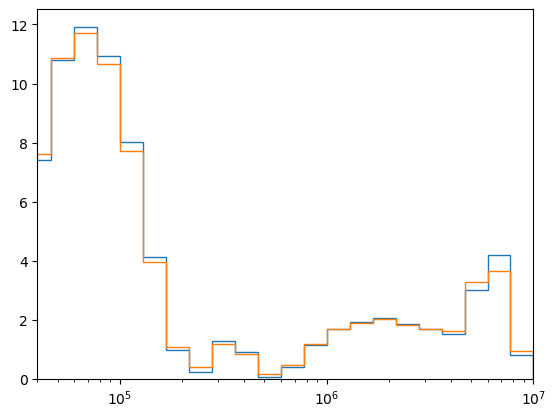

In [21]:

binned_nusiprop, _ = np.histogram(np.asarray(nuSIprop_events_df.index), bins=energy_bins_plotting, weights=nuSIprop_events_df['total_events'])
binned_smeared_nusiprop, _ = np.histogram(np.asarray(nuSIprop_events_df.index), bins=energy_bins_plotting, weights=nuSIprop_smeared)
print(binned_nusiprop)
plt.stairs(binned_nusiprop, energy_bins_plotting)
plt.stairs(binned_smeared_nusiprop, energy_bins_plotting)
plt.xscale('log')
plt.xlim(4*energy_bins_plotting[0], energy_bins_plotting[-1])
plt.show()

Rebin the events to get the same binning as in the plots

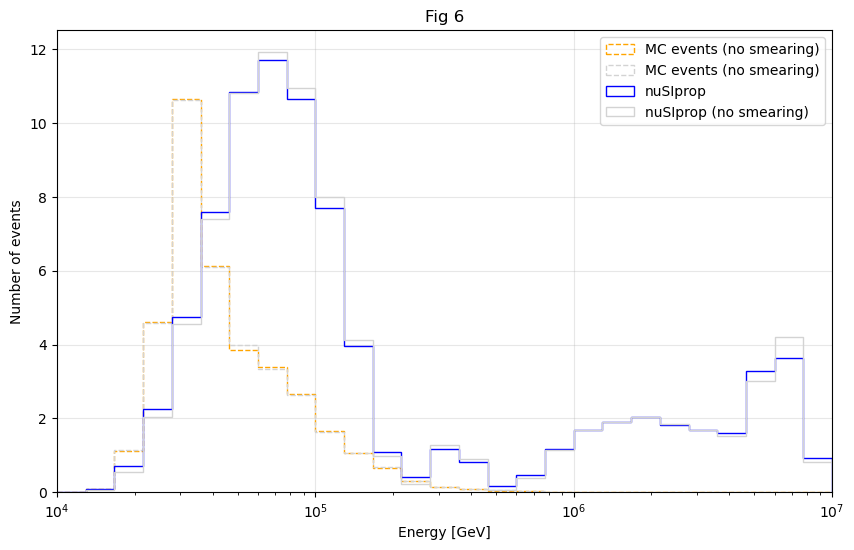

In [40]:

# Create final histogram
#mc_hist, edges = np.histogram(energies_mc, bins=energy_bins_plotting, weights=mc_events)
#mc_hist_smeared, edges = np.histogram(energies_mc, bins=energy_bins_plotting, weights=mc_smeared)

# Plotting
plt.figure(figsize=(10, 6))

plt.hist(
    mc['recoDepositedEnergy'],
    weights=mc_weights[0],
    bins=energy_bins_plotting,
    label='MC events (no smearing)',
    histtype='step',
    color='orange',
    linestyle='--'
)

plt.hist(
    bin_edges_to_centers(energy_bins_high_resolution), 
    weights=mc_events, 
    bins=energy_bins_plotting,
    label='MC events (no smearing)',
    histtype='step',
    color='lightgray',
    linestyle='--'
)

"""plt.hist(  
    energies_mc * 1e-9,
    weights=mc_smeared, 
    bins=energy_bins_plotting, 
    label='MC Events', 
    histtype='step', 
    color='orange'
)"""

# Plot smeared data
plt.hist(
    nuSIprop_events_df.index.values,
    weights=nuSIprop_smeared, 
    bins=energy_bins_plotting, 
    label='nuSIprop', 
    histtype='step', 
    color='blue'
)
plt.hist(
    nuSIprop_events_df.index.values, 
    weights=nuSIprop_events_df['total_events'], 
    bins=energy_bins_plotting,
    label='nuSIprop (no smearing)',
    histtype='step',
    color='lightgray'
)


plt.xscale('log')
plt.xlim(energy_bins_plotting[0], energy_bins_plotting[-1])
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('Fig 6')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

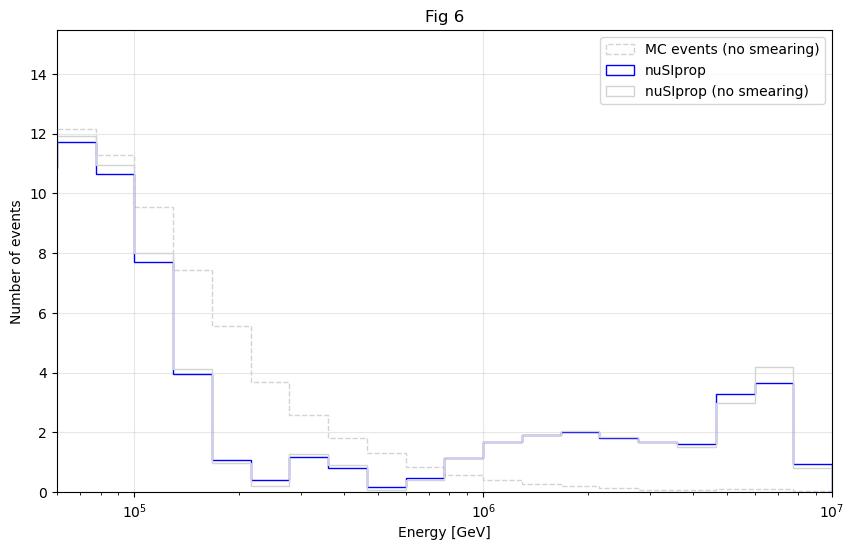

In [34]:
# Create final histogram
#mc_hist, edges = np.histogram(energies_mc, bins=energy_bins_plotting, weights=mc_events)
#mc_hist_smeared, edges = np.histogram(energies_mc, bins=energy_bins_plotting, weights=mc_smeared)

# Plotting
plt.figure(figsize=(10, 6))


plt.hist(
    bin_edges_to_centers(energy_bins_high_resolution), 
    weights=mc_events_test, 
    bins=energy_bins_plotting,
    label='MC events (no smearing)',
    histtype='step',
    color='lightgray',
    linestyle='--'
)
"""plt.hist(  
    energies_mc * 1e-9,
    weights=mc_smeared, 
    bins=energy_bins_plotting, 
    label='MC Events', 
    histtype='step', 
    color='orange'
)"""

# Plot smeared data
plt.hist(
    nuSIprop_events_df.index.values,
    weights=nuSIprop_smeared, 
    bins=energy_bins_plotting, 
    label='nuSIprop', 
    histtype='step', 
    color='blue'
)
plt.hist(
    nuSIprop_events_df.index.values, 
    weights=nuSIprop_events_df['total_events'], 
    bins=energy_bins_plotting,
    label='nuSIprop (no smearing)',
    histtype='step',
    color='lightgray'
)


plt.xscale('log')
plt.xlim(6*energy_bins_plotting[0], energy_bins_plotting[-1])
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('Fig 6')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

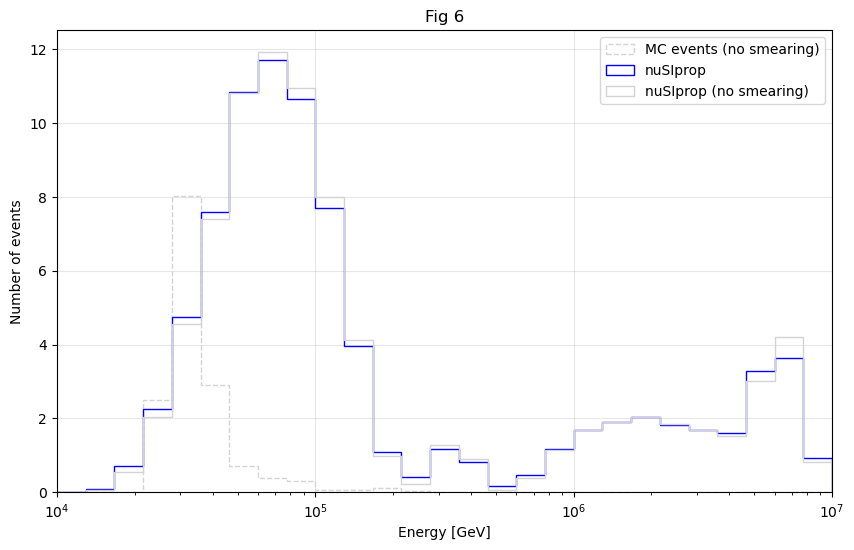

In [31]:
# Create final histogram
#mc_hist, edges = np.histogram(energies_mc, bins=energy_bins_plotting, weights=mc_events)
#mc_hist_smeared, edges = np.histogram(energies_mc, bins=energy_bins_plotting, weights=mc_smeared)

# Plotting
plt.figure(figsize=(10, 6))


plt.hist(
    bin_edges_to_centers(energy_bins_high_resolution), 
    weights=mc_events_test_2, 
    bins=energy_bins_plotting,
    label='MC events (no smearing)',
    histtype='step',
    color='lightgray',
    linestyle='--'
)
"""plt.hist(  
    energies_mc * 1e-9,
    weights=mc_smeared, 
    bins=energy_bins_plotting, 
    label='MC Events', 
    histtype='step', 
    color='orange'
)"""

# Plot smeared data
plt.hist(
    nuSIprop_events_df.index.values,
    weights=nuSIprop_smeared, 
    bins=energy_bins_plotting, 
    label='nuSIprop', 
    histtype='step', 
    color='blue'
)
plt.hist(
    nuSIprop_events_df.index.values, 
    weights=nuSIprop_events_df['total_events'], 
    bins=energy_bins_plotting,
    label='nuSIprop (no smearing)',
    histtype='step',
    color='lightgray'
)


plt.xscale('log')
plt.xlim(energy_bins_plotting[0], energy_bins_plotting[-1])
plt.xlabel('Energy [GeV]')
plt.ylabel('Number of events')
plt.title('Fig 6')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.000000

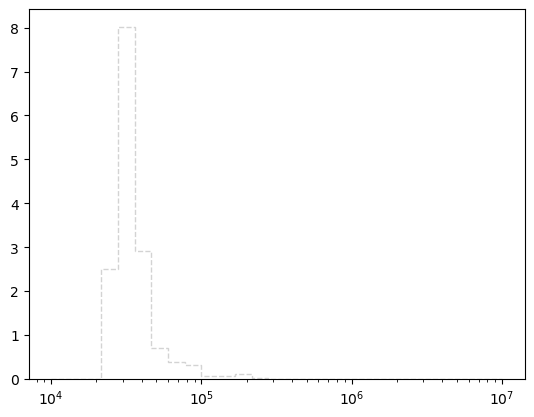

In [33]:
print(mc_events_test_2)
total_events_test_2 = np.sum(mc_events_test_2)
print(total_events_test_2)
plt.hist(
    bin_edges_to_centers(energy_bins_high_resolution), 
    weights=mc_events_test_2, 
    bins=energy_bins_plotting,
    label='MC events (no smearing)',
    histtype='step',
    color='lightgray',
    linestyle='--'
)
plt.xscale('log')
plt.show()